In [ ]:
%%capture
!pip install --upgrade scikit-learn
!pip install --upgrade gensim
!apt-get install git

In [ ]:
%%capture
!git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git

In [ ]:
from google.colab import files
import pandas as pd
import re
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import gensim
import gensim.downloader

import seaborn as sns
import matplotlib.pyplot as plt

def Preprocess(Text):
    msg = re.sub('[^a-zA-Z]', ' ', Text)
    msg = msg.lower()
    msg = msg.split()
    msg = ' '.join(msg)
    return msg

In [ ]:
FTX = gensim.downloader.load('fasttext-wiki-news-subwords-300')

[==================================================] 100.0% 958.5/958.4MB downloaded


In [ ]:
trainset = pd.read_csv("SST-2-sentiment-analysis/data/train.tsv", sep='\t', header=None, names=["class", "review"])
testset = pd.read_csv("SST-2-sentiment-analysis/data/test.tsv", sep='\t', header=None, names=["class", "review"])
trainset["p-review"] = trainset["review"].apply(Preprocess)
testset["p-review"] = testset["review"].apply(Preprocess)


In [ ]:
dim = FTX.vector_size
nTrain = round(len(trainset) * 0.8)

TrainVecs = []
TestVecs = []
print(dim)
for msg in trainset["p-review"]:
  words = msg.split()
  x = np.zeros((len(words), dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TrainVecs.append(torch.FloatTensor(x))

DevVecs = TrainVecs[nTrain:]
TrainVecs = TrainVecs[:nTrain]

for msg in testset["p-review"]:
  words = msg.split()
  x = np.zeros((len(words), dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TestVecs.append(torch.FloatTensor(x))


CTrain = trainset["class"][:nTrain]
CDev = trainset["class"][nTrain:]
CTest = testset["class"]
print(len(CTrain), len(CDev), len(CTest))

300
5536 1384 1821


In [ ]:
dim = FTX.vector_size
nTrain = round(len(trainset) * 0.8)

TrainVecs = []
TestVecs = []
print(dim)
for msg in trainset["p-review"]:
  words = msg.split()
  nwords = len(words)
  if nwords < 5:
    nwords = 5
  x = np.zeros((nwords, dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TrainVecs.append(x)

DevVecs = TrainVecs[nTrain:]
TrainVecs = TrainVecs[:nTrain]

for msg in testset["p-review"]:
  words = msg.split()
  nwords = len(words)
  if nwords < 5:
    nwords = 5
  x = np.zeros((nwords, dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TestVecs.append(x)


CTrain = trainset["class"][:nTrain]
CDev = trainset["class"][nTrain:]
CTest = testset["class"]
print(len(CTrain), len(CDev), len(CTest))

300
5536 1384 1821


In [ ]:
def toBatch(vecs, cls, batchsize=8, dim=dim):
  vecbatches = []
  clsbatches = []
  nvecs = len(vecs)
  for idx in range(nvecs // batchsize):
    maxlen = 0
    for i in range(batchsize):
      slen = len(vecs[idx * batchsize + i])
      if maxlen < slen:
        maxlen = slen
    vecbatch = np.zeros((batchsize, maxlen, dim))
    clsbatch = np.zeros((batchsize))
    for i in range(batchsize):
      clsbatch[i] = cls[idx * batchsize + i]
      slen = len(vecs[idx * batchsize + i])
      if slen < maxlen:
        pad = np.zeros((maxlen - slen, dim))
        vecbatch[i] = np.vstack((vecs[idx * batchsize + i], pad))
      else:
        vecbatch[i] = vecs[idx * batchsize + i]
    vecbatches.append(torch.FloatTensor(vecbatch))
    clsbatches.append(torch.LongTensor(clsbatch))
  return vecbatches, clsbatches


In [ ]:
VecBatches, ClsBatches = toBatch(TrainVecs, CTrain)
TVecBatches, TClsBatches = toBatch(TestVecs, CTest)

Hiệu quả phân lớp khi sử dụng Count Vectorizer

In [ ]:
class Attention(nn.Module):

    def __init__(self, embed_size):
        super().__init__()

        self.Wq = nn.Linear(embed_size, embed_size)
        self.Wk = nn.Linear(embed_size, embed_size)
        self.Wv = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        # x: (batch, seq_len, embed)

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        scores = torch.matmul(Q, K.transpose(-2, -1))

        scores = scores / (Q.size(-1) ** 0.5)

        weights = torch.softmax(scores, dim=-1)

        out = torch.matmul(weights, V)

        return out, weights

# ---------------------------
# Classifier
# ---------------------------

class AttentionClassifier(nn.Module):

    def __init__(self, embed_size):
        super().__init__()

        self.attention = Attention(embed_size)

        self.fc = nn.Linear(embed_size, 2)

    def forward(self, x):
        # x: (batch, seq_len)

        x, weights = self.attention(x)

        x = x.mean(dim=1)

        out = self.fc(x)

        return out, weights

# ---------------------------
# Example Training Script
# ---------------------------

model = AttentionClassifier(dim)

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

criterion = nn.CrossEntropyLoss()
step = 0
for epoch in range(20):
  for X, Y in zip(VecBatches, ClsBatches):
    optimizer.zero_grad()

    output, weights = model(X)
    loss = criterion(output, Y)

    loss.backward()

    #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    if (step % 500 == 0):
      print(step, loss.item())
    step += 1


0 0.6911091208457947
500 0.341487854719162
1000 0.4633070230484009
1500 0.3386206328868866
2000 0.250961035490036
2500 0.25516873598098755
3000 0.6514688730239868
3500 0.1295623481273651
4000 0.45227137207984924
4500 0.4113391637802124
5000 0.16102495789527893
5500 0.666974663734436
6000 0.3150465488433838
6500 0.08029478043317795
7000 0.3014748990535736
7500 0.14559677243232727
8000 0.49654141068458557
8500 0.07593689113855362
9000 0.48836761713027954
9500 0.004052066244184971
10000 0.415861040353775
10500 0.10617935657501221
11000 0.12559111416339874
11500 0.11723247915506363
12000 0.3756423592567444
12500 0.3107999563217163
13000 0.1247660294175148
13500 0.2404244989156723


In [ ]:
def show_attention(sentence, weights):
  words = sentence.split()
  fig, ax = plt.subplots(figsize=(len(words)*0.36 + 0.81 , len(words)*0.36 + 0.81), dpi=100)
  sns.heatmap(weights.detach().cpu().numpy(), ax=ax, cmap="Reds", cbar=False, xticklabels=words, yticklabels=words, linewidths=0.5)
  #ax.set_xticklabels(words, rotation=90, ha="right")
  plt.show()

0


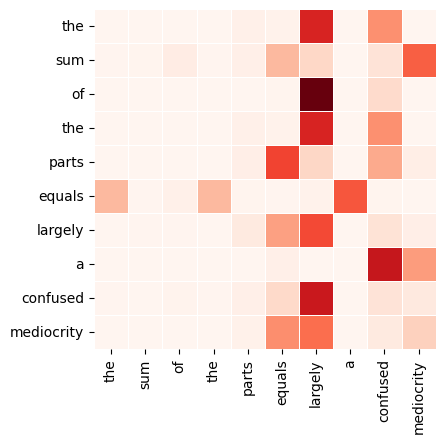

In [ ]:
isample = 53
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])


0


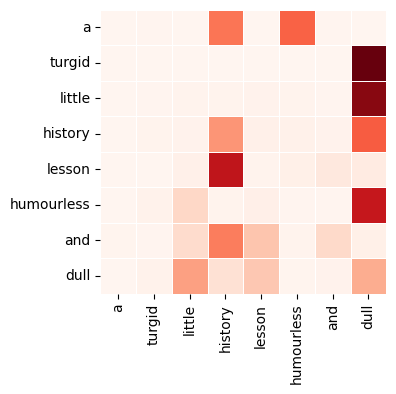

In [ ]:
isample = 67
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])

1


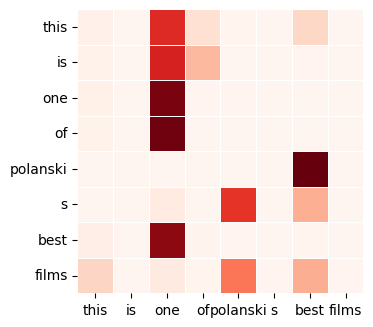

In [ ]:
isample = 4
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])


1


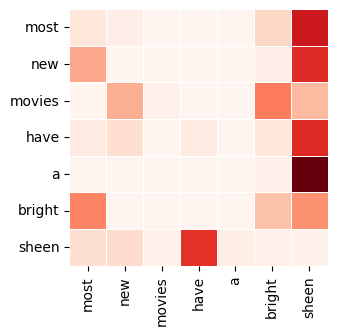

In [ ]:
isample = 20
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])

In [ ]:
model.train(False)
ncorrect = 0
nsamples = 0
for X, Y in zip(TVecBatches, TClsBatches):
  output, weights = model(X)
  plabel = output.argmax(dim=-1)

  for l,pl in zip(Y.detach().numpy(), plabel.detach().numpy()):
    nsamples += 1
    if l == pl:
      ncorrect += 1

print("Accuracy", ncorrect/nsamples)


Accuracy 0.8122246696035242
